In [1]:
import cv2
import numpy as np
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt

In [7]:
INTERIOR_COLORS = {
    (0xFF,0xD7,0x00), (0xFF,0xA5,0x00), (0xEE,0xE8,0xAA),
    (0x6B,0x8E,0x23), (0xAD,0xD8,0xE6), (0xF0,0x80,0x80),
    (0xDD,0xA0,0xDD), (0xDA,0x70,0xD6)
}


In [8]:
image_path = "./data/Tell2Design Data/General Data/floorplan_image/0.png"

In [9]:
img = cv2.imread(image_path)
h, w = img.shape[:2]

# Strict BGR threshold for pure red (entrance line)
b, g, r = cv2.split(img)
red_mask = (r > 200) & (g < 50) & (b < 50)
mask = red_mask.astype(np.uint8) * 255

ys, xs = np.where(red_mask)
pts = np.vstack((xs, ys)).T.astype(np.float32)
if len(pts)<2:
    raise RuntimeError("no red line")

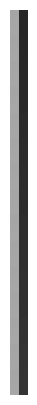

In [21]:
plt.figure(figsize=(5,5))
plt.imshow(pts, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

In [10]:
[vx, vy, x0, y0] = cv2.fitLine(pts, cv2.DIST_L2, 0, 0.01, 0.01)
t = np.array([vx, vy]).reshape(2)

In [28]:
t

array([-4.371139e-08,  1.000000e+00], dtype=float32)

In [13]:
n = np.array([-t[1], t[0]])
n /= np.linalg.norm(n)


# 4) sample two tiny offsets at the line midpoint
mid = np.array([x0, y0]).T

print(mid)
eps = 5
p1 = mid +  eps * n
p2 = mid + -eps * n

def is_interior(pt):
    pt = pt.flatten()
    x,y = int(pt[0]), int(pt[1])

    if not (0 <= x and x <= w and 0 <= y and y <= h): return False
    print(img[y,x])
    return not np.all(img[y, x] == [255,255,255])

# 5) choose which side is interior
if is_interior(p1): 
    interior_n = n
elif is_interior(p2): 
    interior_n = -n
else:
    raise RuntimeError("can't find interior side")

# 6) compute angle from interior_n to “up” (0,-1)
up = np.array([0.0, -1.0])
ang = np.degrees(np.arccos(np.dot(interior_n, up)))
# use cross to get signed
if np.cross(interior_n, up) < 0: ang = -ang
# now find nearest 90° multiple
k = int(np.round(ang / 90)) % 4
rot = k * 90

# 7) rotate around center
M = cv2.getRotationMatrix2D((w/2,h/2), -rot, 1)
out = cv2.warpAffine(img, M, (w,h), flags=cv2.INTER_NEAREST,
                    borderValue=(255,255,255))

[[166.  45.]]
[170 232 238]


In [5]:
coords = np.column_stack(np.where(mask > 0))
if coords.size == 0:
    raise ValueError("No red entrance line detected")
cy, cx = coords.mean(axis=0)

# Sample a vector into the interior (towards image center)
center = np.array([h/2, w/2])
dir_vector = center - np.array([cy, cx])

# Compute current angle, then rotation to make vector point straight up
angle = np.degrees(np.arctan2(dir_vector[0], dir_vector[1]))
desired = 90.0
diff = (desired - angle) % 360
k = int(np.round(diff / 90)) % 4
rot_angle = k * 90

# Perform rotation around center
M = cv2.getRotationMatrix2D((w/2, h/2), -rot_angle, 1.0)
rotated = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_NEAREST, borderValue=(255,255,255))


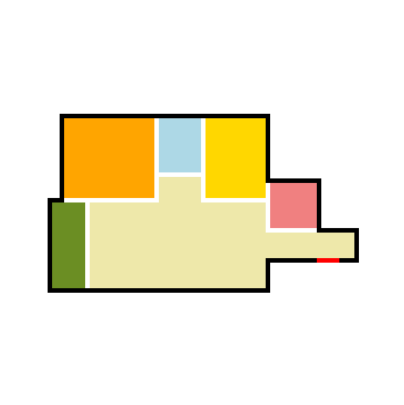

In [51]:
plt.figure(figsize=(5,5))
img_rgb = cv2.cvtColor(out, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb, cmap="gray", vmin=0, vmax=255)
plt.axis('off')
plt.show()

In [3]:
def reorient_floorplan(image):
    img = cv2.imread(image)
    h, w = img.shape[:2]

    # 1) strict red-mask for entrance:
    b,g,r = cv2.split(img)
    red_mask = (r > 200) & (g < 50) & (b < 50)
    ys, xs = np.where(red_mask)
    pts = np.vstack((xs, ys)).T.astype(np.float32)
    if len(pts)<2:
        raise RuntimeError("no red line")

    # 2) fit line through red pixels
    [vx, vy, x0, y0] = cv2.fitLine(pts, cv2.DIST_L2, 0, 0.01, 0.01)
    t = np.array([vx, vy]).reshape(2)  # tangent

    n = np.array([-t[1], t[0]])
    n /= np.linalg.norm(n)


    # 4) sample two tiny offsets at the line midpoint
    mid = np.array([x0, y0]).T

    eps = 5
    p1 = mid +  eps * n
    p2 = mid + -eps * n

    def is_interior(pt):
        pt = pt.flatten()
        x,y = int(pt[0]), int(pt[1])

        if not (0 <= x and x <= w and 0 <= y and y <= h): return False
        print(img[y,x])
        return not np.all(img[y, x] == [255,255,255])

    # 5) choose which side is interior
    if is_interior(p1): 
        interior_n = n
    elif is_interior(p2): 
        interior_n = -n
    else:
        raise RuntimeError("failed to find interior")

    # 6) compute angle from interior_n to “up” (0,-1)
    up = np.array([0.0, -1.0])
    ang = np.degrees(np.arccos(np.dot(interior_n, up)))
    # use cross to get signed
    if np.cross(interior_n, up) < 0: ang = -ang
    # now find nearest 90° multiple
    k = int(np.round(ang / 90)) % 4
    rot = k * 90

    # 7) rotate around center
    M = cv2.getRotationMatrix2D((w/2,h/2), -rot, 1)
    out = cv2.warpAffine(img, M, (w,h), flags=cv2.INTER_NEAREST,
                        borderValue=(255,255,255))
    
    mid = mid.flatten()
    mid_homog = np.array([mid[0], mid[1], 1.0])
    rx, ry = M.dot(mid_homog)
    return out, rot, (float(rx), float(ry))

In [7]:
in_folder  = "./data/Tell2Design Data/General Data/floorplan_image"
out_folder = "./data/Tell2Design Data/General Data/floorplan_reoriented"
os.makedirs(out_folder, exist_ok=True)

In [8]:
csv_path = "reorientation_metadata.csv"
write_header = not os.path.exists(csv_path)

buffer = []
flush_interval = 50
count = 0

In [9]:
for in_path in glob.glob(os.path.join(in_folder, "*.png")):
    fname = os.path.basename(in_path)
    count += 1
    try:
        out_img, angle, (cx, cy)= reorient_floorplan(in_path)
        cv2.imwrite(os.path.join(out_folder, fname), out_img)
        buffer.append({
            "filename": fname,
            "rotation_angle": angle,
            "center_x": cx,
            "center_y": cy,
            "processed": True
        })
        print(f"[OK]   {fname}: rotated {angle}°")
    except Exception as e:
        print(f"[FAIL] {fname}: {e}")
        buffer.append({
            "filename": fname,
            "rotation_angle": float("nan"),
            "center_x": float("nan"),
            "center_y": float("nan"),
            "processed": False
        })

    # Flush every 50 files
    if count % flush_interval == 0:
        df = pd.DataFrame(buffer, columns=["filename","rotation_angle","center_x","center_y","processed"])
        df.to_csv(csv_path, mode='a', header=write_header, index=False)
        write_header = False
        buffer.clear()
        print(f"Flushed log after {count} files.")

# Final flush for any remaining entries
if buffer:
    df = pd.DataFrame(buffer, columns=["filename","rotation_angle","center_x","center_y","processed"])
    df.to_csv(csv_path, mode='a', header=write_header, index=False)
    print(f"Final flush: {len(buffer)} entries.")

print(f"\nDone! Full log at {csv_path}")

[255 255 255]
[170 232 238]
[OK]   40795.png: rotated 0°
[170 232 238]
[OK]   60259.png: rotated 90°
[170 232 238]
[OK]   45409.png: rotated 180°
[170 232 238]
[OK]   22733.png: rotated 180°
[170 232 238]
[OK]   25886.png: rotated 180°
[255 255 255]
[170 232 238]
[OK]   66816.png: rotated 0°
[255 255 255]
[170 232 238]
[OK]   17295.png: rotated 270°
[170 232 238]
[OK]   74616.png: rotated 90°
[170 232 238]
[OK]   6164.png: rotated 180°
[255 255 255]
[170 232 238]
[OK]   23302.png: rotated 270°
[170 232 238]
[OK]   29009.png: rotated 90°
[255 255 255]
[170 232 238]
[OK]   19848.png: rotated 0°
[170 232 238]
[OK]   62293.png: rotated 180°
[255 255 255]
[170 232 238]
[OK]   1004.png: rotated 0°
[170 232 238]
[OK]   72410.png: rotated 90°
[170 232 238]
[OK]   4246.png: rotated 90°
[170 232 238]
[OK]   69872.png: rotated 90°
[170 232 238]
[OK]   7622.png: rotated 180°
[170 232 238]
[OK]   48410.png: rotated 90°
[255 255 255]
[170 232 238]
[OK]   75529.png: rotated 270°
[170 232 238]
[OK]   